# Treinamento DenseNet121 com PyTorch + GPU

Este notebook é uma versão em **PyTorch** para treinar a DenseNet121 usando a GPU no Windows.

Ele mantém a lógica experimental do projeto:

- divisão 60% treino, 20% validação e 20% teste;
- imagens 224x224;
- aumento de dados apenas no treinamento;
- pesos por classe para lidar com desbalanceamento;
- treinamento em duas etapas: cabeça do modelo e fine-tuning;
- métricas finais no conjunto de teste.


In [1]:
import os
# Reduz fragmentação de memória CUDA em testes com imagens maiores.
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import densenet121, DenseNet121_Weights

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA disponível:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.6.0+cu124
Torchvision: 0.21.0+cu124
CUDA disponível: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [ ]:
# Configurações gerais

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Teste mais pesado para a RTX 3050: maior resolução com batch moderado.
# Se ocorrer CUDA out of memory, reduza BATCH_SIZE para 8.
IMG_SIZE = (448, 448)
BATCH_SIZE = 16
NUM_CLASSES = 5

NUM_WORKERS = 8
PIN_MEMORY = torch.cuda.is_available()

EPOCHS_HEAD = 10
EPOCHS_FINE_TUNING = 20

HEAD_LEARNING_RATE = 1e-3
FINE_TUNING_LEARNING_RATE = 1e-5

DROPOUT_RATE = 0.3
PATIENCE = 6

CLASS_WEIGHT_MODE = "sqrt"  # opções: "balanced", "sqrt", "none"

MODEL_NAME = "DenseNet121"
MODEL_KEY = "densenet121_pytorch_gpu"
EXPERIMENT_NAME = "v2_pytorch_gpu_448_bs16_workers8_ft_denseblock4_lr1e5"
MODEL_OUTPUT_KEY = f"{MODEL_KEY}_{EXPERIMENT_NAME}"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo usado:", device)

Dispositivo usado: cuda


In [3]:
# Caminhos do projeto

cwd = Path.cwd().resolve()

# Funciona tanto se o notebook for executado da raiz do projeto quanto de dentro de notebooks/
if cwd.name == "notebooks":
    PROJECT_DIR = cwd.parent
else:
    PROJECT_DIR = cwd

SPLITS_DIR = PROJECT_DIR / "data" / "splits"
RAW_IMAGES_DIR = PROJECT_DIR / "data" / "raw" / "train_images"

RESULTS_DIR = PROJECT_DIR / "results"
METRICS_DIR = RESULTS_DIR / "metrics"
FIGURES_DIR = RESULTS_DIR / "figures"
MODELS_DIR = PROJECT_DIR / "models"

METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_OUTPUT_DIR = MODELS_DIR / MODEL_OUTPUT_KEY
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("SPLITS_DIR:", SPLITS_DIR)
print("RAW_IMAGES_DIR:", RAW_IMAGES_DIR)
print("MODEL_OUTPUT_DIR:", MODEL_OUTPUT_DIR)

PROJECT_DIR: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica
SPLITS_DIR: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/data/splits
RAW_IMAGES_DIR: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/data/raw/train_images
MODEL_OUTPUT_DIR: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/models/densenet121_pytorch_gpu_v2_pytorch_gpu_448_bs16_workers8_ft_denseblock4_lr1e5


In [4]:
# Carregar splits

train_df = pd.read_csv(SPLITS_DIR / "train_split.csv")
val_df = pd.read_csv(SPLITS_DIR / "val_split.csv")
test_df = pd.read_csv(SPLITS_DIR / "test_split.csv")

def corrigir_caminhos(df):
    df = df.copy()
    df["image_path"] = df["id_code"].apply(
        lambda image_id: str((RAW_IMAGES_DIR / f"{image_id}.png").resolve())
    )
    return df

train_df = corrigir_caminhos(train_df)
val_df = corrigir_caminhos(val_df)
test_df = corrigir_caminhos(test_df)

print("Treino:", train_df.shape)
print("Validação:", val_df.shape)
print("Teste:", test_df.shape)

train_df.head()

Treino: (2197, 3)
Validação: (732, 3)
Teste: (733, 3)


,id_code,diagnosis,image_path
0,9df31421cdd2,2,/home/avell/Documentos/Caio/tcc-retinopatia-di...
1,d3de0d313d61,1,/home/avell/Documentos/Caio/tcc-retinopatia-di...
2,bb85097857fa,0,/home/avell/Documentos/Caio/tcc-retinopatia-di...
3,abf09c44d5f4,2,/home/avell/Documentos/Caio/tcc-retinopatia-di...
4,187f6ccda87a,4,/home/avell/Documentos/Caio/tcc-retinopatia-di...


In [5]:
# Verificar imagens ausentes

def verificar_imagens(df, nome):
    missing = df[~df["image_path"].apply(lambda path: Path(path).exists())]
    print(f"{nome}:")
    print("Total:", len(df))
    print("Imagens ausentes:", len(missing))
    if len(missing) > 0:
        display(missing.head())
        raise FileNotFoundError(f"Existem imagens ausentes em {nome}.")

verificar_imagens(train_df, "Treino")
verificar_imagens(val_df, "Validação")
verificar_imagens(test_df, "Teste")

Treino:
Total: 2197
Imagens ausentes: 0
Validação:
Total: 732
Imagens ausentes: 0
Teste:
Total: 733
Imagens ausentes: 0


In [6]:
# Nomes das classes

class_names = {
    0: "Sem retinopatia",
    1: "Retinopatia leve",
    2: "Retinopatia moderada",
    3: "Retinopatia severa",
    4: "Retinopatia proliferativa",
}

class_labels = [class_names[i] for i in range(NUM_CLASSES)]

print(class_labels)

['Sem retinopatia', 'Retinopatia leve', 'Retinopatia moderada', 'Retinopatia severa', 'Retinopatia proliferativa']


In [7]:
# Transformações

# Normalização padrão ImageNet, compatível com modelos pré-treinados do torchvision.
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomRotation(degrees=8),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05),
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

In [8]:
# Dataset e DataLoader

class AptosDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row["image_path"]
        label = int(row["diagnosis"])

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label


train_dataset = AptosDataset(train_df, transform=train_transform)
val_dataset = AptosDataset(val_df, transform=eval_transform)
test_dataset = AptosDataset(test_df, transform=eval_transform)

# No Linux, múltiplos workers ajudam a alimentar melhor a GPU.
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=True,
)

images, labels = next(iter(train_loader))
print("Batch imagens:", images.shape)
print("Batch rótulos:", labels.shape)
print("Dtype imagens:", images.dtype)
print("Dtype rótulos:", labels.dtype)

Batch imagens: torch.Size([16, 3, 448, 448])
Batch rótulos: torch.Size([16])
Dtype imagens: torch.float32
Dtype rótulos: torch.int64


In [9]:
# Pesos por classe

classes = np.unique(train_df["diagnosis"].values)

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["diagnosis"].values
)

class_weights_balanced = {
    int(class_id): float(weight)
    for class_id, weight in zip(classes, class_weights_values)
}

class_weights_sqrt = {
    class_id: float(np.sqrt(weight))
    for class_id, weight in class_weights_balanced.items()
}

if CLASS_WEIGHT_MODE == "balanced":
    class_weights = class_weights_balanced
elif CLASS_WEIGHT_MODE == "sqrt":
    class_weights = class_weights_sqrt
elif CLASS_WEIGHT_MODE == "none":
    class_weights = None
else:
    raise ValueError("CLASS_WEIGHT_MODE deve ser 'balanced', 'sqrt' ou 'none'.")

print("Class weights balanceados:")
print(class_weights_balanced)

print("\nClass weights suavizados:")
print(class_weights_sqrt)

print("\nClass weights usados neste experimento:")
print(class_weights)

if class_weights is not None:
    weight_tensor = torch.tensor(
        [class_weights[i] for i in range(NUM_CLASSES)],
        dtype=torch.float32,
        device=device
    )
else:
    weight_tensor = None

criterion = nn.CrossEntropyLoss(weight=weight_tensor)

Class weights balanceados:
{0: 0.405724838411819, 1: 1.9792792792792793, 2: 0.7335559265442404, 3: 3.787931034482759, 4: 2.4824858757062147}

Class weights suavizados:
{0: 0.6369653353298114, 1: 1.4068686076813568, 2: 0.8564787951515439, 3: 1.9462607827531127, 4: 1.5755906434433453}

Class weights usados neste experimento:
{0: 0.405724838411819, 1: 1.9792792792792793, 2: 0.7335559265442404, 3: 3.787931034482759, 4: 2.4824858757062147}


In [10]:
# Criar modelo DenseNet121

weights = DenseNet121_Weights.DEFAULT
model = densenet121(weights=weights)

# Congelar todas as camadas inicialmente.
for param in model.parameters():
    param.requires_grad = False

# Trocar a cabeça final.
in_features = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=DROPOUT_RATE),
    nn.Linear(in_features, NUM_CLASSES)
)

model = model.to(device)

# Apenas a cabeça treina na primeira etapa.
optimizer_head = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=HEAD_LEARNING_RATE
)

scheduler_head = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_head,
    mode="min",
    factor=0.2,
    patience=3,
    min_lr=1e-7
)

print(model.classifier)

# Teste de forward
model.eval()
with torch.no_grad():
    sample_images = images.to(device)
    preds = model(sample_images)
    print("Predições:", preds.shape)


Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1024, out_features=5, bias=True)
)
Predições: torch.Size([16, 5])


In [11]:
# Funções de treino e avaliação

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(predicted.cpu().numpy().tolist())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)


def fit_phase(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    epochs,
    checkpoint_path,
    phase_name,
    patience=PATIENCE,
):
    history = []

    best_val_loss = float("inf")
    best_epoch = 0
    patience_counter = 0

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        val_loss, val_acc, _, _ = evaluate(
            model, val_loader, criterion, device
        )

        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        row = {
            "phase": phase_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "learning_rate": current_lr,
        }
        history.append(row)

        print(
            f"[{phase_name}] Época {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | lr={current_lr:.2e}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            patience_counter = 0
            torch.save(model.state_dict(), checkpoint_path)
            print(f"  Melhor modelo salvo em: {checkpoint_path}")
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping na fase {phase_name}. Melhor época: {best_epoch}")
            break

    phase_time = time.time() - start_time

    # Restaurar melhor checkpoint da fase.
    try:
        state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    except TypeError:
        state_dict = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state_dict)

    return history, phase_time

In [12]:
# Treinar cabeça do modelo

checkpoint_head_path = MODEL_OUTPUT_DIR / f"{MODEL_OUTPUT_KEY}_head_best.pt"

history_head, head_training_time = fit_phase(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_head,
    scheduler=scheduler_head,
    device=device,
    epochs=EPOCHS_HEAD,
    checkpoint_path=checkpoint_head_path,
    phase_name="head",
)

print(f"Tempo de treinamento da cabeça: {head_training_time:.2f} segundos")

[head] Época 01/10 | train_loss=1.4587 train_acc=0.4980 | val_loss=1.3712 val_acc=0.6585 | lr=1.00e-03
  Melhor modelo salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/models/densenet121_pytorch_gpu_v2_pytorch_gpu_448_bs16_workers8_ft_denseblock4_lr1e5/densenet121_pytorch_gpu_v2_pytorch_gpu_448_bs16_workers8_ft_denseblock4_lr1e5_head_best.pt
[head] Época 02/10 | train_loss=1.2280 train_acc=0.6113 | val_loss=1.1325 val_acc=0.7691 | lr=1.00e-03
  Melhor modelo salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/models/densenet121_pytorch_gpu_v2_pytorch_gpu_448_bs16_workers8_ft_denseblock4_lr1e5/densenet121_pytorch_gpu_v2_pytorch_gpu_448_bs16_workers8_ft_denseblock4_lr1e5_head_best.pt
[head] Época 03/10 | train_loss=1.1553 train_acc=0.6350 | val_loss=1.0831 val_acc=0.6626 | lr=1.00e-03
  Melhor modelo salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/models/densenet121_pytorch_gpu_v2_pytorch_gpu_448_bs16_workers8_ft_denseblock4_lr1e5/densenet121_py

In [13]:
# Fine-tuning: descongelar o último bloco denso e a cabeça final.

for name, param in model.named_parameters():
    if (
        name.startswith("features.denseblock4")
        or name.startswith("features.norm5")
        or name.startswith("classifier")
    ):
        param.requires_grad = True
    else:
        param.requires_grad = False

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print("Parâmetros treináveis:", trainable_params)
print("Parâmetros totais:", total_params)

optimizer_fine = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=FINE_TUNING_LEARNING_RATE
)

scheduler_fine = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_fine,
    mode="min",
    factor=0.2,
    patience=3,
    min_lr=1e-7
)


Parâmetros treináveis: 2165253
Parâmetros totais: 6958981


In [14]:
# Treinar fine-tuning

checkpoint_fine_path = MODEL_OUTPUT_DIR / f"{MODEL_OUTPUT_KEY}_fine_best.pt"

history_fine, fine_tuning_time = fit_phase(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_fine,
    scheduler=scheduler_fine,
    device=device,
    epochs=EPOCHS_FINE_TUNING,
    checkpoint_path=checkpoint_fine_path,
    phase_name="fine_tuning",
)

print(f"Tempo de fine-tuning: {fine_tuning_time:.2f} segundos")

[fine_tuning] Época 01/20 | train_loss=0.9523 train_acc=0.6818 | val_loss=0.9591 val_acc=0.7596 | lr=1.00e-05
  Melhor modelo salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/models/densenet121_pytorch_gpu_v2_pytorch_gpu_448_bs16_workers8_ft_denseblock4_lr1e5/densenet121_pytorch_gpu_v2_pytorch_gpu_448_bs16_workers8_ft_denseblock4_lr1e5_fine_best.pt
[fine_tuning] Época 02/20 | train_loss=0.9352 train_acc=0.7114 | val_loss=0.9429 val_acc=0.7650 | lr=1.00e-05
  Melhor modelo salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/models/densenet121_pytorch_gpu_v2_pytorch_gpu_448_bs16_workers8_ft_denseblock4_lr1e5/densenet121_pytorch_gpu_v2_pytorch_gpu_448_bs16_workers8_ft_denseblock4_lr1e5_fine_best.pt
[fine_tuning] Época 03/20 | train_loss=0.9151 train_acc=0.7201 | val_loss=0.9354 val_acc=0.7732 | lr=1.00e-05
  Melhor modelo salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/models/densenet121_pytorch_gpu_v2_pytorch_gpu_448_bs16_workers8_ft_denseblock4

In [15]:
# Consolidar histórico

history_df = pd.DataFrame(history_head + history_fine)
history_path = METRICS_DIR / f"{MODEL_OUTPUT_KEY}_history.csv"
history_df.to_csv(history_path, index=False, encoding="utf-8-sig")

print("Histórico salvo em:", history_path)
history_df.tail()

Histórico salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/results/metrics/densenet121_pytorch_gpu_v2_pytorch_gpu_448_bs16_workers8_ft_denseblock4_lr1e5_history.csv


,phase,epoch,train_loss,train_accuracy,val_loss,val_accuracy,learning_rate
25,fine_tuning,16,0.758960,0.772417,0.884285,0.804645,0.000010
26,fine_tuning,17,0.741437,0.784706,0.891434,0.792350,0.000010
27,fine_tuning,18,0.743261,0.778334,0.877917,0.806011,0.000010
28,fine_tuning,19,0.728249,0.789713,0.884116,0.800546,0.000002
29,fine_tuning,20,0.734976,0.783796,0.899692,0.781421,0.000002


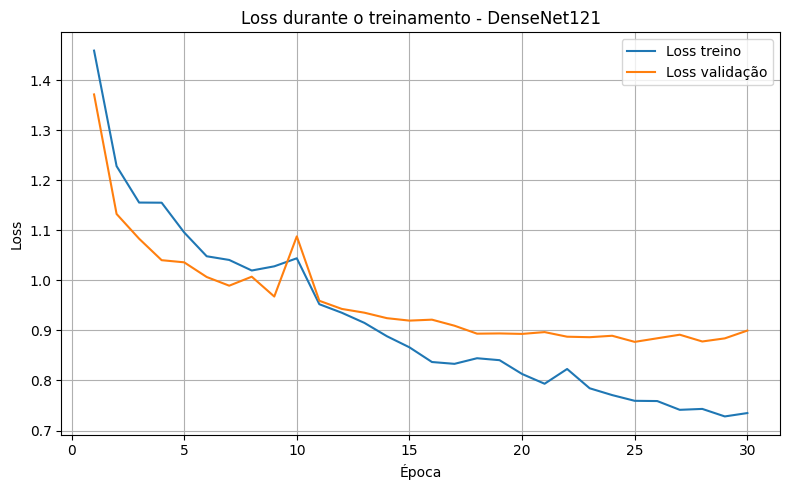

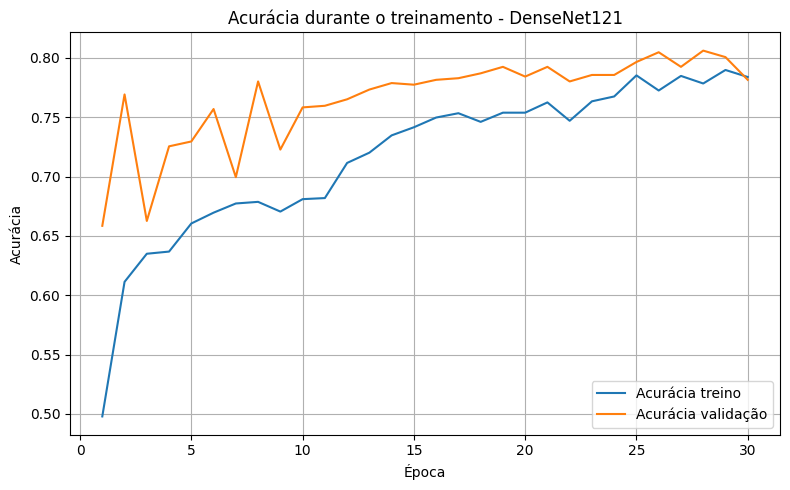

Figuras salvas em:
/home/avell/Documentos/Caio/tcc-retinopatia-diabetica/results/figures/densenet121_pytorch_gpu_v2_pytorch_gpu_448_bs16_workers8_ft_denseblock4_lr1e5_loss.png
/home/avell/Documentos/Caio/tcc-retinopatia-diabetica/results/figures/densenet121_pytorch_gpu_v2_pytorch_gpu_448_bs16_workers8_ft_denseblock4_lr1e5_accuracy.png


In [16]:
# Gráficos de loss e acurácia

plt.figure(figsize=(8, 5))
plt.plot(history_df.index + 1, history_df["train_loss"], label="Loss treino")
plt.plot(history_df.index + 1, history_df["val_loss"], label="Loss validação")
plt.title(f"Loss durante o treinamento - {MODEL_NAME}")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_fig_path = FIGURES_DIR / f"{MODEL_OUTPUT_KEY}_loss.png"
plt.savefig(loss_fig_path, dpi=300)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(history_df.index + 1, history_df["train_accuracy"], label="Acurácia treino")
plt.plot(history_df.index + 1, history_df["val_accuracy"], label="Acurácia validação")
plt.title(f"Acurácia durante o treinamento - {MODEL_NAME}")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(True)
plt.tight_layout()

acc_fig_path = FIGURES_DIR / f"{MODEL_OUTPUT_KEY}_accuracy.png"
plt.savefig(acc_fig_path, dpi=300)
plt.show()

print("Figuras salvas em:")
print(loss_fig_path)
print(acc_fig_path)

In [17]:
# Avaliação final no conjunto de teste

test_loss, test_accuracy, y_true, y_pred = evaluate(
    model, test_loader, criterion, device
)

print("Loss no teste:", test_loss)
print("Acurácia no teste:", test_accuracy)

Loss no teste: 0.7726032450937477
Acurácia no teste: 0.7926330150068213


In [18]:
# Relatório de classificação

report = classification_report(
    y_true,
    y_pred,
    target_names=class_labels,
    digits=4
)

print(report)

report_path = METRICS_DIR / f"{MODEL_OUTPUT_KEY}_classification_report.txt"
report_path.write_text(report, encoding="utf-8")

print("Relatório salvo em:", report_path)

                           precision    recall  f1-score   support

          Sem retinopatia     0.9721    0.9668    0.9694       361
         Retinopatia leve     0.5474    0.7027    0.6154        74
     Retinopatia moderada     0.7922    0.6100    0.6893       200
       Retinopatia severa     0.3671    0.7436    0.4915        39
Retinopatia proliferativa     0.6304    0.4915    0.5524        59

                 accuracy                         0.7926       733
                macro avg     0.6618    0.7029    0.6636       733
             weighted avg     0.8205    0.7926    0.7983       733

Relatório salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/results/metrics/densenet121_pytorch_gpu_v2_pytorch_gpu_448_bs16_workers8_ft_denseblock4_lr1e5_classification_report.txt


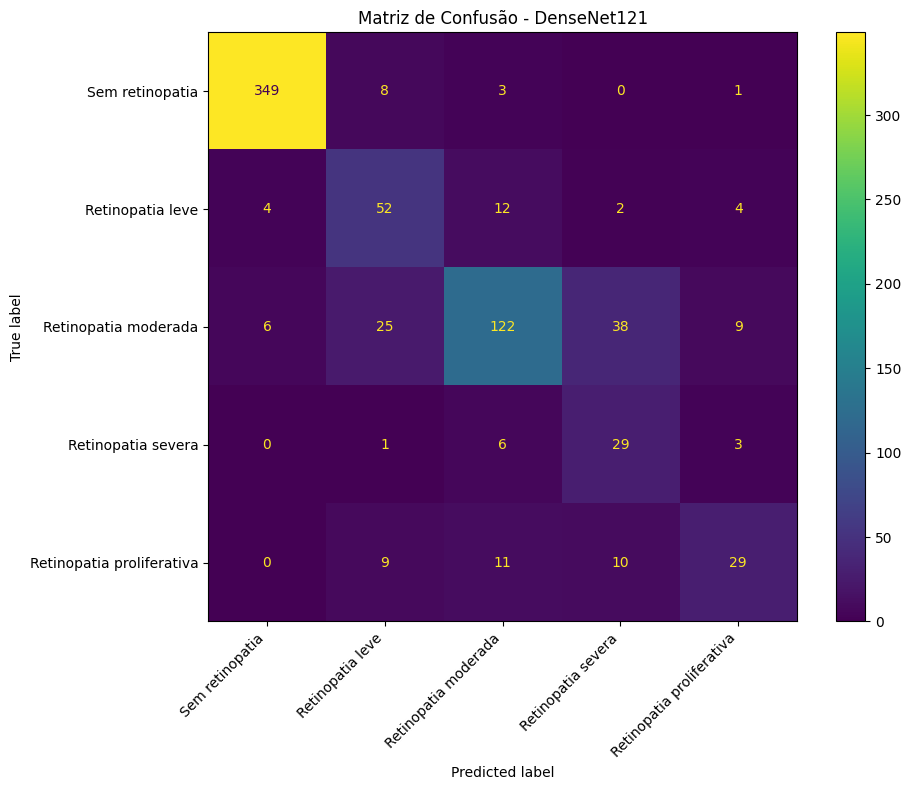

Matriz salva em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/results/metrics/densenet121_pytorch_gpu_v2_pytorch_gpu_448_bs16_workers8_ft_denseblock4_lr1e5_confusion_matrix.csv
Figura salva em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/results/figures/densenet121_pytorch_gpu_v2_pytorch_gpu_448_bs16_workers8_ft_denseblock4_lr1e5_confusion_matrix.png


In [19]:
# Matriz de confusão

cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=class_labels,
    columns=class_labels
)

cm_path = METRICS_DIR / f"{MODEL_OUTPUT_KEY}_confusion_matrix.csv"
cm_df.to_csv(cm_path, encoding="utf-8-sig")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_labels
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap="viridis", values_format="d")
plt.title(f"Matriz de Confusão - {MODEL_NAME}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

cm_fig_path = FIGURES_DIR / f"{MODEL_OUTPUT_KEY}_confusion_matrix.png"
plt.savefig(cm_fig_path, dpi=300)
plt.show()

print("Matriz salva em:", cm_path)
print("Figura salva em:", cm_fig_path)

In [ ]:
# Salvar modelo final e resumo de métricas

final_model_path = MODEL_OUTPUT_DIR / f"{MODEL_OUTPUT_KEY}_final.pt"
torch.save(model.state_dict(), final_model_path)

summary_metrics = {
    "model": MODEL_NAME,
    "framework": "PyTorch",
    "experiment_name": EXPERIMENT_NAME,
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "epochs_head_configured": EPOCHS_HEAD,
    "epochs_fine_tuning_configured": EPOCHS_FINE_TUNING,
    "epochs_completed_total": int(len(history_df)),
    "batch_size": BATCH_SIZE,
    "image_size": list(IMG_SIZE),
    "dropout_rate": DROPOUT_RATE,
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
    "persistent_workers": True,
    "class_weight_mode": CLASS_WEIGHT_MODE,
    "class_weights": class_weights,
    "split_strategy": "60% treino / 20% validação / 20% teste",
    "preprocess_input": "torchvision.transforms.Normalize(mean=ImageNet, std=ImageNet)",
    "data_augmentation": {
        "Resize": list(IMG_SIZE),
        "RandomRotation": 8,
        "RandomAffine_translate": [0.03, 0.03],
        "RandomAffine_scale": [0.95, 1.05],
        "RandomHorizontalFlip": 0.5,
    },
    "run_fine_tuning": True,
    "fine_tuning_layers": "features.denseblock4 + features.norm5 + classifier",
    "head_learning_rate": HEAD_LEARNING_RATE,
    "fine_tuning_learning_rate": FINE_TUNING_LEARNING_RATE,
    "head_training_time_seconds": float(head_training_time),
    "fine_tuning_time_seconds": float(fine_tuning_time),
    "gpu_available": torch.cuda.is_available(),
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "final_model_path": str(final_model_path),
    "best_head_checkpoint_path": str(checkpoint_head_path),
    "best_fine_checkpoint_path": str(checkpoint_fine_path),
}

summary_path = METRICS_DIR / f"{MODEL_OUTPUT_KEY}_summary_metrics.json"

with summary_path.open("w", encoding="utf-8") as f:
    json.dump(summary_metrics, f, indent=4, ensure_ascii=False)

print("Modelo final salvo em:", final_model_path)
print("Resumo salvo em:", summary_path)

Modelo final salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/models/densenet121_pytorch_gpu_v2_pytorch_gpu_448_bs16_workers8_ft_denseblock4_lr1e5/densenet121_pytorch_gpu_v2_pytorch_gpu_448_bs16_workers8_ft_denseblock4_lr1e5_final.pt
Resumo salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/results/metrics/densenet121_pytorch_gpu_v2_pytorch_gpu_448_bs16_workers8_ft_denseblock4_lr1e5_summary_metrics.json


: 

## Observações

Este notebook usa PyTorch e GPU CUDA. Para comparação final no TCC, utilize versões equivalentes para EfficientNetB0, ResNet50 e DenseNet121, mantendo a mesma divisão, mesmo batch size, mesmas transformações, mesmos pesos por classe e estratégia de fine-tuning equivalente.
